In [ ]:
# =================================================================
# MINERÍA DE DATOS - SEMANA 3: EDA Y ANÁLISIS MULTIVARIADO
# Estudiante: Martín Ozuna
# =================================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
# 1. CARGA DE DATOS Y EXPLORACIÓN INICIAL (EDA)
np.random.seed(42)
n_clientes = 50
data = {
    'Cliente': np.arange(1, n_clientes + 1),
    'Edad': np.random.randint(20, 65, n_clientes),
    'Ingresos': np.random.normal(50000, 15000, n_clientes).round(2),
    'Experiencia': np.random.randint(0, 40, n_clientes)
}

# Ajuste para que la experiencia no supere la edad razonablemente
data['Experiencia'] = [min(exp, edad - 18) if edad > 18 else 0 for exp, edad in zip(data['Experiencia'], data['Edad'])]

df = pd.DataFrame(data)

print("--- Análisis Estadístico Univariado ---")
stats = df[['Edad', 'Ingresos', 'Experiencia']].agg(['mean', 'std', 'skew', 'kurtosis']).T
print(stats)

--- Análisis Estadístico Univariado ---
                  mean           std      skew  kurtosis
Edad            41.760     12.846917  0.051890 -0.999443
Ingresos     51037.692  16008.167573  0.681176  0.869307
Experiencia     13.700     10.345560  0.345622 -1.141975


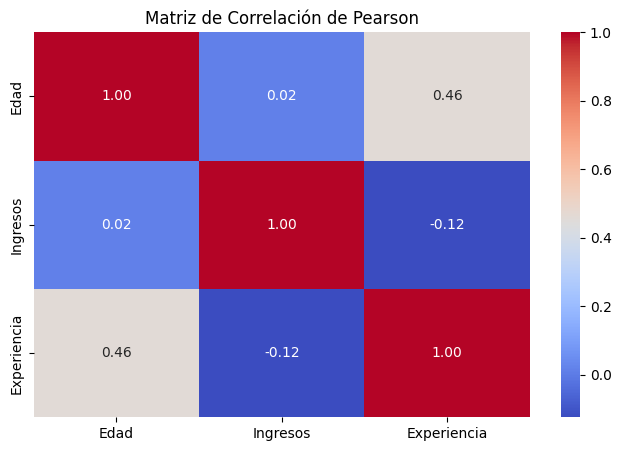

In [4]:
# 2. ANÁLISIS DE CORRELACIÓN
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Edad', 'Ingresos', 'Experiencia']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Pearson")
plt.show()

In [ ]:
# 3. PREPROCESAMIENTO (NORMALIZACIÓN)
# Justificación: PCA y K-Means requieren datos en la misma escala para evitar sesgos.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['Edad', 'Ingresos', 'Experiencia']])

In [ ]:
# 4. APLICACIÓN DE PCA
pca = PCA()
pca_data = pca.fit_transform(df_scaled)

In [ ]:
# Cálculo de Varianza Explicada Acumulada
varianza_acum = np.cumsum(pca.explained_variance_ratio_)
print(f"\nVarianza explicada por las primeras 2 componentes: {varianza_acum[1]:.2%}")

In [ ]:
# 5. SEGMENTACIÓN CON K-MEANS (3 CLUSTERS)
# Aplicamos sobre las 2 primeras componentes de PCA
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_PCA'] = kmeans_pca.fit_predict(pca_data[:, :2])

In [ ]:
# 6. VISUALIZACIÓN DE CLUSTERS
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df['Cluster_PCA'], cmap='viridis', s=100)
plt.title('Segmentación de Clientes en el Espacio PCA (2D)')
plt.xlabel('Componente Principal 1 (Estatus Socio-Económico)')
plt.ylabel('Componente Principal 2 (Edad/Madurez)')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
# Resumen de resultados por Cluster
print("\n--- Perfil promedio por Cluster ---")
print(df.groupby('Cluster_PCA')[['Edad', 'Ingresos', 'Experiencia']].mean())